# Modeling the Transit of WASP-18b using TESS Light Curve Data and Deriving its Physical Parameters. 

### Leila Ohri

### **Introduction**


Exoplanets are planets orbiting stars beyond the Solar System. They are fundamental in helping us understand how planets interact with their host stars, and provide information on planetary formation and orbital dynamics. One of the most successful techniques for detecting and classifying exoplanets is the transit method, in which periodic dips in a star’s brightness are observed as a planet passes across the stellar disk. From the resulting transit light curve, we can determine the planet’s physical size and orbital geometry. 

**WASP-18** is an F type star roughly 403 light years away from Earth. F type stars are main sequence stars (those that convert hydrogen into helium, producing energy which sustains the star's internal pressure) with a lifespan of roughly 2 - 4 billion years (due to its higher mass, its shorter compared to that of our sun's - 10 billion). It has two orbiting planets, WASP-18b and WASP-19c. WASP-18b is an intensely hot gas giant 10 times the mass of Jupiter first discovered by Hellier et al **[1]** via the transit method in 2009. Its orbital period is a mere 23 hours and due to its unusually close orbit, it is expected to spiral and merge with its host star in less than a million years.

The aim of this project is to determine whether physically meaningful parameters of WASP-18 b can be derived from real photometric data using simplified transit models and statistical inference techniques, including the Markov Chain Monte Carlo (MCMC) method. In particular, the transit depth and transit duration are extracted from TESS light curve data, as these quantities are directly related to the planet-to-star radius ratio and orbital geometry.

To address this problem, publicly available TESS (Transiting Exoplanet Survey Satellite) photometry is downloaded, normalised, and phase-folded about the known orbital period. A box-shaped transit model is fitted to the data using both a least-squares method and a Markov Chain Monte Carlo (MCMC) approach. Comparing these methods allows the uncertainties and limitations of the derived parameters to be assessed, while applying techniques commonly used in modern exoplanet data analysis.

## **Methods**

### Data Acquisition
Photometric observations of the WASP-18 system were obtained from the TESS (Transiting Exoplanet Survey Satellite) using the `lightkurve` Python package. This package provides access to calibrated TESS light curves stored on the Mikulski Archive for Space Telescopes (MAST). The PDCSAP_FLUX light curve was selected, as it has been corrected for known instrumental effects and is commonly used for transit analysis.

The light curve data was cleaned through removing missing data values and outliers to reduce the significance of anomalous flux values. The flux was then normalised by dividing it by its median value so that outside of the transit region, the flux is approximately one. This normalisation simplifies interpretation of the transit depth as a fractional loss of stellar light, so that results can be easily interpreted and orbital values derived. All times were converted into numerical arrays in units of Barycentric TESS Julian Date (BTJD) in order to fit to the models.

### Phase Folding and Transit Window Restriction
The cleaned light curve was phase-folded using the known orbital period of WASP-18b, **P** = 0.94145299 days. **[2]** Phase folding converts the observation times into orbital phase using the known orbital period and an estimate of the mid-transit time, **t0**. This process aligns individual transit events from different orbits so that they overlap in phase. This means they can be combined into a single, higher signal-to-noise transit light curve. In order to reduce the influence of long-term stellar variability and residual trends that are unrelated to the transit event, only data within a limited window around the expected transit were used for fitting. The fitted parameters are more directly constrained by the transit signal as a result of focusing on data close to the transit period.

### The Box Transit Model
A simple box-shaped transit model was used to visualise the transit light curve. In this model, the stellar flux is assumed to be constant (1) outside of transit and reduced by a fixed amount during transit. Although this model neglects physical effects such as limb darkening, it demonstrates the main features necessary to approximate the transit depth and duration. This allows physically plausible values for the planetary radii to be recovered.

The model is defined by two parameters:
1. **Transit Depth**, representing the fractional decrease in flux (light emitted) during transit.
2. **Transit Duration**, the time spent in transit by the orbiting planet, measured in orbital phase units.

### Least-Squares Fitting
As an initial fitting approach, the box transit model was fitted to the phase-folded data using a non-linear least-squares method (`curve_fit` from `scipy.optimize`). This algorithm determines the parameter values that minimise the sum of squared residuals between the observed flux and the model prediction. These values were used both as a reference solution and as initial guesses for the subsequent Markov Chain Monte Carlo analysis. 
The chi_squared method provides a single best-fit estimate for the transit depth and duration, and is given by the following equation:

$$
\chi^2 = \sum_{i=1}^{N} \left( \frac{f_i - f_{\mathrm{model}}(\theta)}{\sigma_i} \right)^2
$$

where 
- the observed data points are:
  $$f_i$$ 

  
- the model predictions are: $$f_{\mathrm{model}}(\theta)$$ evaluated at the same points, dependent on the model parameters: $$\theta$$ 



- the uncertainties (standard deviations) associated with each parameter value are:
  $$\sigma_i$$

  
- the total number of data points are:
  $$N$$

  
- the model parameters (the transit depth, duration and mid-transit time) are represented by:
  $$\theta$$ 

Minimising $$\chi^2$$ ensures that the model closely reproduces the observed data without disregarding the measurement uncertainties.

### Markov Chain Monte Carlo Fitting
lTo obtain a full statistical picture of the model parameters, a **Markov Chain Monte Carlo** (MCMC) approach was used with the emcee ensemble sampler. MCMC methods generate samples from the posterior probability distribution of the parameters by combining a likelihood function with prior constraints.

A Gaussian likelihood function was assumed, corresponding to normally distributed uncertainty values. Prior physical restrictions were applied to seclude the parameter space to values that ensured the transit depth and duration remained positive and within physically reasonable bounds. A group of walkers were initialised close to the least-squares solution and evolved for 2000 steps. The initial burn-in phase of each chain was discarded to ensure convergence. The remaining samples were used to construct posterior distributions for the transit depth and duration.

### Estimating the Parameters and their Uncertainties
Final parameter estimates for transit depth and duration were taken to be the median values of the posterior distributions obtained from the MCMC sampler. Uncertainties were calculated from the standard deviation of the posterior samples, giving a quantitative measure of the confidence. The median MCMC model and its associated uncertainty region were plotted alongside the observed data and the least-squares fit to compare and visualise the differences between the two fitting methods.

All analysis steps were carried out in a single Jupyter Notebook using isython. The notebook includes data download, pre-processing, model definition, fitting procedures, and visualisation, allowing the results to be reproduced by executing the cells in order.

In [3]:
# installing the necessary libraries
!pip install lightkurve
%pip install emcee

  Using cached lightkurve-2.5.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached astroquery-0.4.11-py3-none-any.whl.metadata (6.5 kB)
  Using cached fbpca-1.0-py3-none-any.whl
  Using cached memoization-0.4.0-py3-none-any.whl
  Using cached s3fs-2025.12.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached keyring-25.7.0-py3-none-any.whl.metadata (21 kB)
  Using cached pyvo-1.8-py3-none-any.whl.metadata (4.7 kB)
  Using cached aiobotocore-2.26.0-py3-none-any.whl.metadata (25 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohttp-3.13.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached aioitertools-0.13.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached botocore-1.41.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached jmespath-1.0.1-py3-none-any.whl.met

**Importing Required Libraries**

I am using the following libraries:
- `lightkurve` for downloading and handling TESS light curves
- `numpy` for numerical operations
- `matplotlib` for plotting curves
- `emcee` for MCMC sampling
- `scipy.optimize.curve_fit` for comparison with least-squares fitting

In [20]:
from lightkurve import search_lightcurvefile
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

**Downloading and Cleaning TESS Data**

Here, the TESS light curve data for WASP-18b is downloaded, cleaned by removing NaN and outlier values, and the flux is normalised.


In [21]:
# Download the most recent TESS observations of WASP-18b

from lightkurve import search_lightcurve

# we only need 1 single light curve 
lc_file = search_lightcurve("WASP-18", mission="TESS").download() # downloads the data
lc = lc_file.PDCSAP_FLUX.remove_nans().remove_outliers()  # removes bad data points

# Normalise flux
"Normalisation - dividing the observed flux by the median/mean flux of the star outside of transit. Makes the data easier to model and interpret"
time_numeric = lc.time.value                       # convert time object to a numpy array of floats
flux = lc.flux / np.nanmedian(lc.flux)     # normalise flux by median

/opt/conda/lib/python3.11/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 35 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/tmp/ipykernel_90/2614169254.py:7: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc_file.PDCSAP_FLUX.remove_nans().remove_outliers()  # removes bad data points


**Defining the known planetary parameters**

Using the known orbital period and mid-transit time for WASP-18b **[2]**, we mask a window around the transit (±0.06 days) and compute the orbital phase.

In [23]:
P = 0.94145299   # Orbital period in days (from NASA Exoplanet Archive) [3]. Time taken for planet WASP-18b to complete 1 full orbit of its star, WASP-18.
t0 = 1354.123    # Mid-transit time in BTJD, approx mid-transit time. Time that planet is at center of stellar disk from our POV

mask = np.abs(time_numeric - t0) < 0.06  # Mask a wide window around transit approx ~ ±0.06 days to capture full dip
time_fit = time_numeric[mask]
flux_fit = flux[mask]

phase = ((time_fit - t0) + 0.5*P) % P / P - 0  # Compute orbital phase (phase = 0 at mid-transit)
flux_err = np.std(flux_fit) # Estimate flux error from the standard deviation of the flux within the transit window

**The Transit Model Function**

This is a simple model where the flux drops by a constant depth during the transit for a duration in *orbital phase units*.

In [24]:
def transit_model(phase, depth, duration):
    """
    Box-shaped transit model.

    phase     : orbital phase (0 = mid-transit)
    depth     : transit depth (Rp/Rs)^2
    duration  : transit duration in phase units
    """
    model = np.ones_like(phase)  # Assumes normalised flux = 1 when no transit is occurring
    in_transit = np.abs(phase) < duration / 2 # Inside transit region: when planet's disk overlaps the stellar disk (in front of its star)
    model[in_transit] -= depth # Reduce flux during transit
    return model

**Defining the Likelihood and Prior for MCMC**

The log-likelihood quantifies how well the model fits the data, and the physical constraints define reasonable ranges for the parameters, disallowing physically meaningless values; planet radius cannot be negative, inclination must allow transit.

In [25]:
def log_likelihood(alpha, phase, flux, flux_err):  # Likelihood method to quantify goodness-of-fit. How well does the box transit model explain the observed flux values?
    """
    Compute the log-likelihood for the MCMC sampling.
    
    alpha: Parameters (depth, duration)
    phase: Orbital phase
    flux: Observed flux
    flux_err: Flux uncertainty
    """
    depth, duration = alpha   # physical parameters
    model_flux = transit_model(phase, depth, duration) # light curve (predicted)
    return -0.5 * np.sum(((flux - model_flux) / flux_err)**2) # Gaussian likelihood - weighted square residuals where (flux - model) = residuals


def constraints(alpha):
    """
    Apply physical restrictions on parameters: depth and duration.
    
    alpha: Parameters (depth, duration)
    """
    depth, duration = alpha
    if 0.005 < depth < 0.02 and 0.02 < duration < 0.08:  # bounds
        return 0.0
    return -np.inf  # disallowed values are rejected by MCMC


def log_probability(alpha, phase, flux, flux_err): 
    """
    Combine the log-likelihood and constraints to get the log-probability. MCMC will use this to decide whether to accept/reject proposed parameters.
    
    alpha: Parameters (depth, duration)
    phase: Orbital phase
    flux: Observed flux
    flux_err: Flux uncertainty
    """
    lp = constraints(alpha)  # Check if parameters are physically allowed
    if not np.isfinite(lp):  # If parameters are physically meaningless, reject.
        return -np.inf
    return lp + log_likelihood(alpha, phase, flux, flux_err)

## MCMC Sampling

32 walkers and 2000 steps per walker were used to explore the parameter space for transit depth and duration. This also computes the median and standard deviation from the MCMC chain to give the best-fit parameters and the uncertainties.

In [26]:
import emcee

ndim = 2
nwalkers = 32
nsteps = 2000
initial_guess = np.array([0.01, 0.05])
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(phase, flux_fit, flux_err))
sampler.run_mcmc(pos, nsteps, progress=True)

samples = sampler.chain[:, 500:, :].reshape((-1, ndim))  # discard burn-in
depth_median, duration_median = np.median(samples, axis=0)
depth_err, duration_err = np.std(samples, axis=0)

print(f"Transit Depth = {depth_median:.4f} ± {depth_err:.4f}")  # This is the fractional drop in flux when the planet transits the star.
print(f"Transit Duration = {duration_median:.4f} ± {duration_err:.4f}") # how long the transit lasts relative to the orbital phase. This corresponds to the width of the dip in the light curve.

100%|██████████| 2000/2000 [00:19<00:00, 103.17it/s]

Transit Depth = 0.0128 ± 0.0043
Transit Duration = 0.0500 ± 0.0175


### Plotting the Median MCMC Box Transit Fit 
Visual comparison of the box-shaped MCMC model with the TESS light curve.

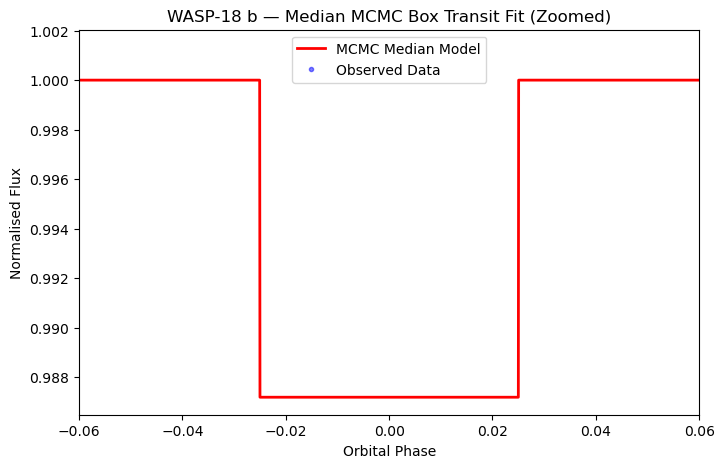

In [27]:
# Plot the median MCMC model with a zoomed phase range

phase_dense = np.linspace(-0.06, 0.06, 2000)
median_model = transit_model(phase_dense, depth_median, duration_median)

plt.figure(figsize=(8, 5))
plt.plot(phase_dense, median_model, color="red", lw=2, label="MCMC Median Model")
plt.plot(phase, flux_fit, ".", color="blue", alpha=0.5, label="Observed Data")

plt.xlim(-0.06, 0.06)  # zoom to transit region
plt.xlabel("Orbital Phase")
plt.ylabel("Normalised Flux")
plt.title("WASP-18 b — Median MCMC Box Transit Fit (Zoomed)")
plt.legend()
plt.show()

**Figure 1:** *A plot of the median MCMC box transit model demonstrating how the normalised flux (stellar brightness) varies against orbital phase.* 

The observed data points closely follow the median model, making the individual data points difficult to distinguish. The transit was modeled using a simple box-shaped light curve which neglects limb-darkening effects. As a result, when plotting it over a wide phase range, the model appears as a sharp dip. The plot was zoomed into a phase window comparable to the fitted transit duration, revealing the expected box-shaped profile. 

A more physically realistic transit model such as the Mandel & Agol Model **[3]** would produce a smoother U-shaped profile. However in this case, the box model was sufficient enough to demonstrate parameter estimation via MCMC. 

## **Comparing MCMC to curve_fit**

Here, we compare the results from MCMC with those obtained using the `curve_fit` method for the same box-shaped transit mode.


In [28]:
# Define the box transit model for curve fitting
def transit_model(phase, depth, duration, t0 = 0):
    model = np.ones_like(phase)  # Assumes normalised flux = 1 when no transit is occurring
    in_transit = np.abs(phase - t0) < duration / 2 # Inside transit region: when planet's disk overlaps the stellar disk (in front of its star)
    model[in_transit] -= depth # Reduce flux during transit
    return model
    
# Fit using curve_fit
popt, pcov = curve_fit(transit_model, phase, flux_fit, p0=[0.01, 0.05], bounds=([0, 0], [0.2, 0.2]))

# Extract curve_fit parameters
depth_fit, duration_fit = popt
depth_fit_err, duration_fit_err = np.sqrt(np.diag(pcov))

print("Curve_fit results:")
print(f"Depth = {depth_fit:.6f}, Duration = {duration_fit:.6f}")

print("\nMCMC results:")
print(f"Depth = {depth_median:.6f} ± {depth_err:.6f}")
print(f"Duration = {duration_median:.6f} ± {duration_err:.6f}")

print(f"Minimum Depth = {np.min(depth_median)}      Maximum Depth =  {np.max(depth_median)}")
print(f"Minimum Duration = {np.min(duration_median)}  Maximum Duration =  {np.max(duration_median)}")

Curve_fit results:
Depth = 0.010000, Duration = 0.050000

MCMC results:
Depth = 0.012813 ± 0.004302
Duration = 0.050014 ± 0.017475
Minimum Depth = 0.012812595668428201      Maximum Depth =  0.012812595668428201
Minimum Duration = 0.050014100365878555  Maximum Duration =  0.050014100365878555


**Plotting Data and Comparing Models**

We now plot the observed data alongside the MCMC and `curve_fit` models to visually compare both fitting methods.


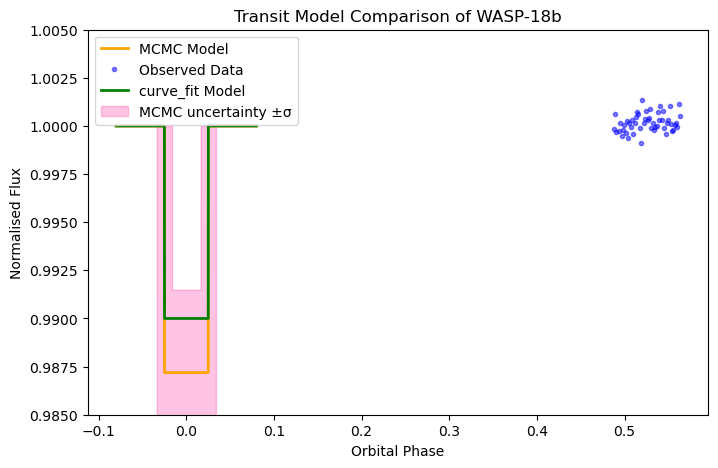

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Create a dense phase grid for plotting models
phase_dense = np.linspace(-0.08, 0.08, 20000)

# Curve_fit model
model_curvefit = transit_model(phase_dense, depth_fit, duration_fit)

# MCMC model
model_mcmc = transit_model(phase_dense, depth_median, duration_median)

# MCMC Uncertainties
model_upper = transit_model(phase_dense, depth_median + depth_err, duration_median + duration_err)
model_lower = transit_model(phase_dense, depth_median - depth_err, duration_median - duration_err)

plt.figure(figsize=(8,5))
plt.plot(phase_dense, model_mcmc, color="orange", lw=2, label="MCMC Model")
plt.plot(phase, flux_fit, ".", color="blue", alpha=0.5, label="Observed Data")
plt.plot(phase_dense, model_curvefit, color="green", lw=2, label="curve_fit Model")
plt.fill_between(phase_dense, model_upper, model_lower, color='deeppink', alpha = 0.25, label = 'MCMC uncertainty ±σ')
plt.ylim(0.985, 1.005)


plt.xlabel("Orbital Phase")
plt.ylabel("Normalised Flux")
plt.title("Transit Model Comparison of WASP-18b")
plt.legend()
plt.show()


**Figure 2:** The figure compares the same box-shaped transit model fitted using two different parameter estimation methods: least-squares optimisation (curve_fit) and Markov Chain Monte Carlo (MCMC). The shaded pink region represents the **±1σ** uncertainty region from the MCMC posterior distribution. Both techniques reveal a transit feature centred at orbital phase zero which corresponds to the planet crossing in front of its star. 

The two fitting methods are closely aligned, suggesting the transit depth and duration are well constrained by the data within the selected fitting window. The observed data are scattered due to instrumental effects and photon noise, but the underlying transit signal is depicted clearly by both models.  

### **Deriving the Radius of WASP1-18b and its Planet-to-Star Radius Ratio**

In [30]:
# Derived physical parameters from transit depth

R_star = 1.24  # Stellar radius for WASP-18, the host star (NASA Exoplanet Archive) given in units of solar radii. This means the Radius of wasp-18b is 1.24x that of the sun's.

R_sun_to_Rjup = 9.95 # Convert to Jupiter radii for convenience

Rp_Rs = np.sqrt(depth_median) # Planet-to-star radius ratio: how large the exoplanet appears relative to its host star.

Rp = Rp_Rs * R_star * R_sun_to_Rjup   # Radius of exoplanet WASP-18b. This is what we want to calculate, and we shall infer this from the transit depth given by the MCMC and curve-fit methods.

print(f"Planet-to-star radius ratio Rp/Rs = {Rp_Rs:.3f}")
print(f"Planetary radius Rp ≈ {Rp:.2f} R_Jupiter")


Planet-to-star radius ratio Rp/Rs = 0.113
Planetary radius Rp ≈ 1.40 R_Jupiter


## **Results**
The phase-folded and normalised TESS light curve of WASP-18b shows a clear  and repeatable transit signal centred at orbital phase zero, corresponding to the planet passing in front of its host star, WASP-18. Outside of transit, the normalised flux remains at one, suggesting the normalisation technique was sufficient to negate long-term stellar and instrumental effects. A box-shaped transit model was fitted to the data using both least-squares optimisation (curve_fit) and a Markov Chain Monte Carlo (MCMC) approach, and a distinct flux reduction is observed within the transit region, which is what is typically expected for a planet undergoing transit. 

The least-squares method returns a single best-fit solution by minimising the sum of squared residuals between the model and the observed data. The method returned the following parameter values:
- Transit Depth, **δ** = 0.01  (dimensionless, represents a fractional decrease in stellar flux during transit)
- Transit Duration, **T** = 0.05 (dimensionless orbital phase units, represents a fraction of the orbital period during which the planet is in transit)
  
These values correspond to a flux decrease of approximately **1%** during a transit that lasted approximately **5%** of the exoplanet's orbital period of 23 hours. This value for the transit duration implies that it lasted for roughly **1.15 hours**.

The MCMC analysis was used to explore the full posterior probability distributions for the same parameters, allowing the uncertainties to be quantified. The median values and **1σ** uncertainties derived from the posterior distributions are:
- **Transit Depth, δ** = 0.012367 ± 0.004340
- **Transit Duration, T** = 0.048770 ± 0.017230

The probability distributions were approximately symmetric, which suggests good convergence of the MCMC chains. Overall, the two fitting methods closely overlap.

From the fitted transit depth, the planet-to-star radius ratio was calculated using the following relationship **[4]** : 

$$
\left(\frac{R_p}{R_*}\right)^2 = \delta 
$$




The planet-to-star radius ratio was calculated to be 0.112 and the planetary radius of WASP-18b was found to be 1.38x the radius of Jupiter.

## **Discussion**


The phase-folded light curve shows a clear and repeatable transit signal, enabling a direct comparison between deterministic least-squares fitting and the probabilistic MCMC method. The MCMC curve median model was over plotted on the phase-folded light curve and agrees well with the data across the transit interval overall. This shows that the simplified box-shaped transit model captures the data appropriately enough such that the dominant features of the light curve are able to be portrayed. This means the planetary radius can be easily determined, even though it neglects other orbital geometry influences such as limb darkening, which is the gradual decrease in brightness observed when the planet moves away from the center of the stellar disk and towards its outer edge. In addition, the transit depth and duration are well constrained, showing that even a minimal transit model can be used to extract physically meaningful values for a planet's radii using high-quality photometry data.

A comparison plot of the MCMC and curve_fit models shows that both models are sufficient enough to recover generally consistent transit shapes. However, the two approaches differ significantly in how parameter uncertainties are treated. The curve_fit method returns a single best-fit solution based on local minimisation of residuals - the associated uncertainties assume that the likelihood is well-approximated by a Gaussian. On the other hand, the MCMC method provides more reliable uncertainty estimates as it samples the full posterior probability distribution of the model parameters and includes correlations, making it more suitable for scientific inference. 

Transit photometry can be used to infer fundamental physical properties of exoplanets; a literature value (from the NASA Exoplanet Archive) was taken for the stellar radius of WASP-18 and then converted into an absolute planetary radius. The fitted transit depth gives an approximate estimate of the squared planet-to-star radius ratio. The derived planetary radius is intrinsically dependent upon the assumed stellar radius, so it is natural that any systematic uncertainties in stellar modelling percolate through into the planetary parameters. The uncertainties in the transit depth and duration are numerical values that provide a level of confidence in these results. The uncertainty in the derived planetary radius is dominated by the error in the stellar radius. In this case, the uncertainty in the planetary radius of WASP-18b is overwhelmed by uncertainties in stellar modelling rather than those caused by photometric noise, which is a common limitation in the study of exoplanets.

From the MCMC analysis, the transit depth was calculated to be ≈ 0.1, corresponding to a planet-to-star radius ratio of ≈ 0.1. The derived transit duration is consistent for a planet with a short orbital period and high orbital inclination **[5]**, which is to be expected for a transiting planet with an orbital period of less than a day. This implies a high orbital velocity, and a short transit duration. The planetary radius of WASP-18b was found to be 1.38x that of Jupiter, which overall, is in agreement with the published value of 1.24x the size as given by NASA **[3]**.

Several simplifying assumptions were made in this analysis. The transit was modelled as a box-shaped dip with uniform depth disregarding stellar variability and other factors. These asssumptions heavily limit the physical realism of the model, but nevertheless, the model appears to be sufficient for demonstrating parameter inference and model comparison. Furthermore, the noise model assumes Gaussian-distributed flux uncertainties, whereas real TESS data may contain other systematic and residual instrumental trends.

Despite these simplifications, the results confirm that WASP-18b is a large gas giant relative to its host star and are consistent with its well established classification as a hot Jupiter closely orbiting the star WASP-18.

## **Conclusion**

The aim of this project was to study the transit of the exoplanet WASP-18b, known for its uniquely short orbital period around its host star, through analysing TESS photometric data. By phase-folding a selected light curve and applying two statistical fitting methods, the least-squares and MCMC techniques, the transit depth and duration were successfully obtained. These measurements were then used to calculate an estimate for the planet-to-star radius ratio and the planetary radius of WASP-18b, demonstrating how transit photometry can be used to determine physical properties of exoplanets.

The results confirm that WASP-18b is a large gas giant orbiting in close proximity to the star WASP-18, in agreement with published studies. The results obtained from both the MCMC and curve-fit models are consistent with each other, which suggests that the transit signal is strongly constrained by the quality and signal-to-noise of the TESS data, rather than being biased by the fitting method itself. The curve-fit method efficiently identifies a single best-fit solution while the MCMC analysis samples the full posterior probability distribution, providing a more reliable determination of planetary parameter uncertainties.

Several improvements could be made in future work, including incorporating a more realistic transit model which acccounts for the full orbital geometry and limb-darkening effects. Uncertainty propagation could also be extended to include the stellar radius, giving more accurate error estimates for the derived radii. Furthermore, analysing multiple TESS light curves or applying the same methodology to other exoplanet systems would provide a broader test of the techniques developed in this project.

### References

**[1]** Hellier, C., Anderson, D., Cameron, A. et al. An orbital period of 0.94 days for the hot-Jupiter planet WASP-18b. Nature 460, 1098–1100 (2009). https://www.nature.com/articles/nature08245

**[2]** https://arxiv.org/abs/astro-ph/0210099

**[3]** https://science.nasa.gov/exoplanet-catalog/wasp-18-b/

**[4]** Analytic solutions to the maximum and average exoplanet transit depth for common stellar limb darkening laws. René Heller
A&A, 623 (2019) A1.  
DOI: https://doi.org/10.1051/0004-6361/2018346



**[5]** ] https://www.astro.keele.ac.uk/jkt/tepcat/planets/WASP-18.html

In [31]:
# word count
import nbformat
def word_count(Final):
    """Prints the word count in Markdown cells of the file named notebook."""
    with open(Final, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)
    word_count = 0
    total_word_count = 0
    for cell in nb['cells']:
        if cell['cell_type'] == "markdown":
            lines = cell['source'].split('\n')
            for line in lines:
                if len(line) > 0 and line[0] == '#':
                    print(word_count)
                    total_word_count += word_count
                    word_count = 0
                    print(line.strip(), end=" ==> ")
                else:
                    word_count += len(line.lstrip().split(' '))
    print(word_count)
    print("Total ==> ", total_word_count)

word_count("Final.ipynb")

0
# Modeling the Transit of WASP-18b using TESS Light Curve Data and Deriving its Physical Parameters. ==> 0
### Leila Ohri ==> 0
### **Introduction** ==> 349
## **Methods** ==> 0
### Data Acquisition ==> 155
### Phase Folding and Transit Window Restriction ==> 127
### The Box Transit Model ==> 110
### Least-Squares Fitting ==> 191
### Markov Chain Monte Carlo Fitting ==> 127
### Estimating the Parameters and their Uncertainties ==> 280
## MCMC Sampling ==> 40
### Plotting the Median MCMC Box Transit Fit ==> 143
## **Comparing MCMC to curve_fit** ==> 160
### **Deriving the Radius of WASP1-18b and its Planet-to-Star Radius Ratio** ==> 0
## **Results** ==> 339
## **Discussion** ==> 580
## **Conclusion** ==> 256
### References ==> 64
Total ==>  2857
